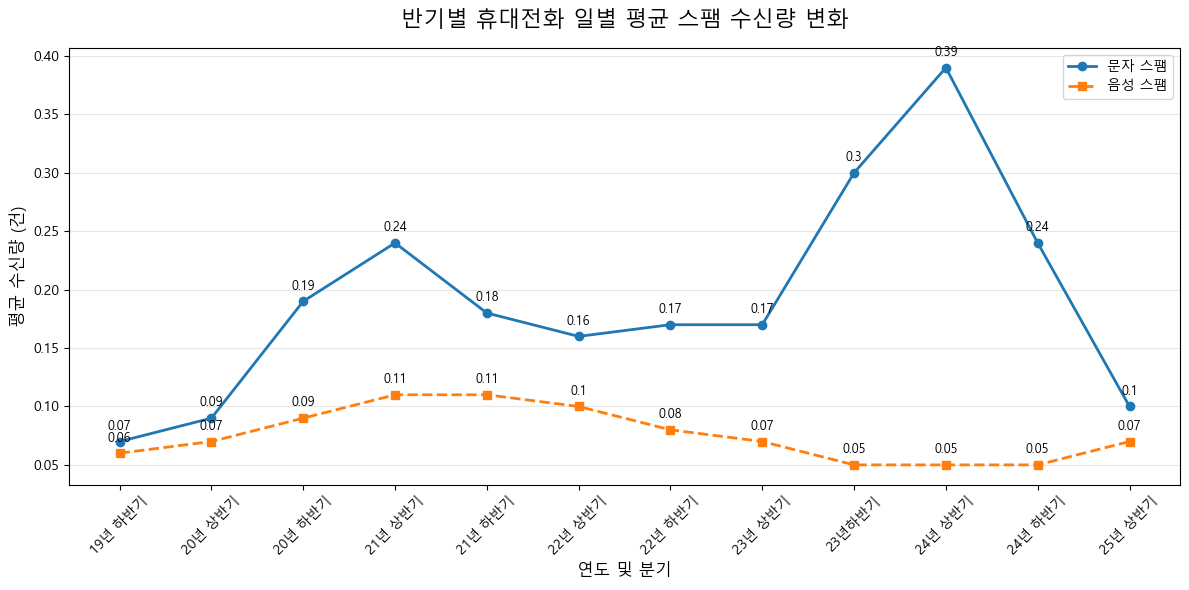

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 로드
file_path = '반기별_휴대전화_일별평균스팸수신량.csv'
df = pd.read_csv(file_path, index_col=0, encoding='cp949')

# 2. 데이터 전처리 (시각화를 위해 행과 열을 바꿈)
df_t = df.transpose()

# 3. 시각화 설정 (한글 깨짐 방지)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 4. 그래프 그리기
plt.figure(figsize=(12, 6))

# 문자 스팸 추이
plt.plot(df_t.index, df_t['문자'], marker='o', linestyle='-', linewidth=2, label='문자 스팸')
# 음성 스팸 추이
plt.plot(df_t.index, df_t['음성'], marker='s', linestyle='--', linewidth=2, label='음성 스팸')

# 5. 그래프 꾸미기
plt.title('반기별 휴대전화 일별 평균 스팸 수신량 변화', fontsize=16, pad=15)
plt.xlabel('연도 및 분기', fontsize=12)
plt.ylabel('평균 수신량 (건)', fontsize=12)
plt.xticks(rotation=45) # X축 라벨이 겹치지 않도록 회전
plt.grid(True, axis='y', alpha=0.3)
plt.legend()

# 수치 표시
for i, v in enumerate(df_t['문자']):
    plt.text(i, v + 0.01, str(v), ha='center', fontsize=9)
for i, v in enumerate(df_t['음성']):
    plt.text(i, v + 0.01, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

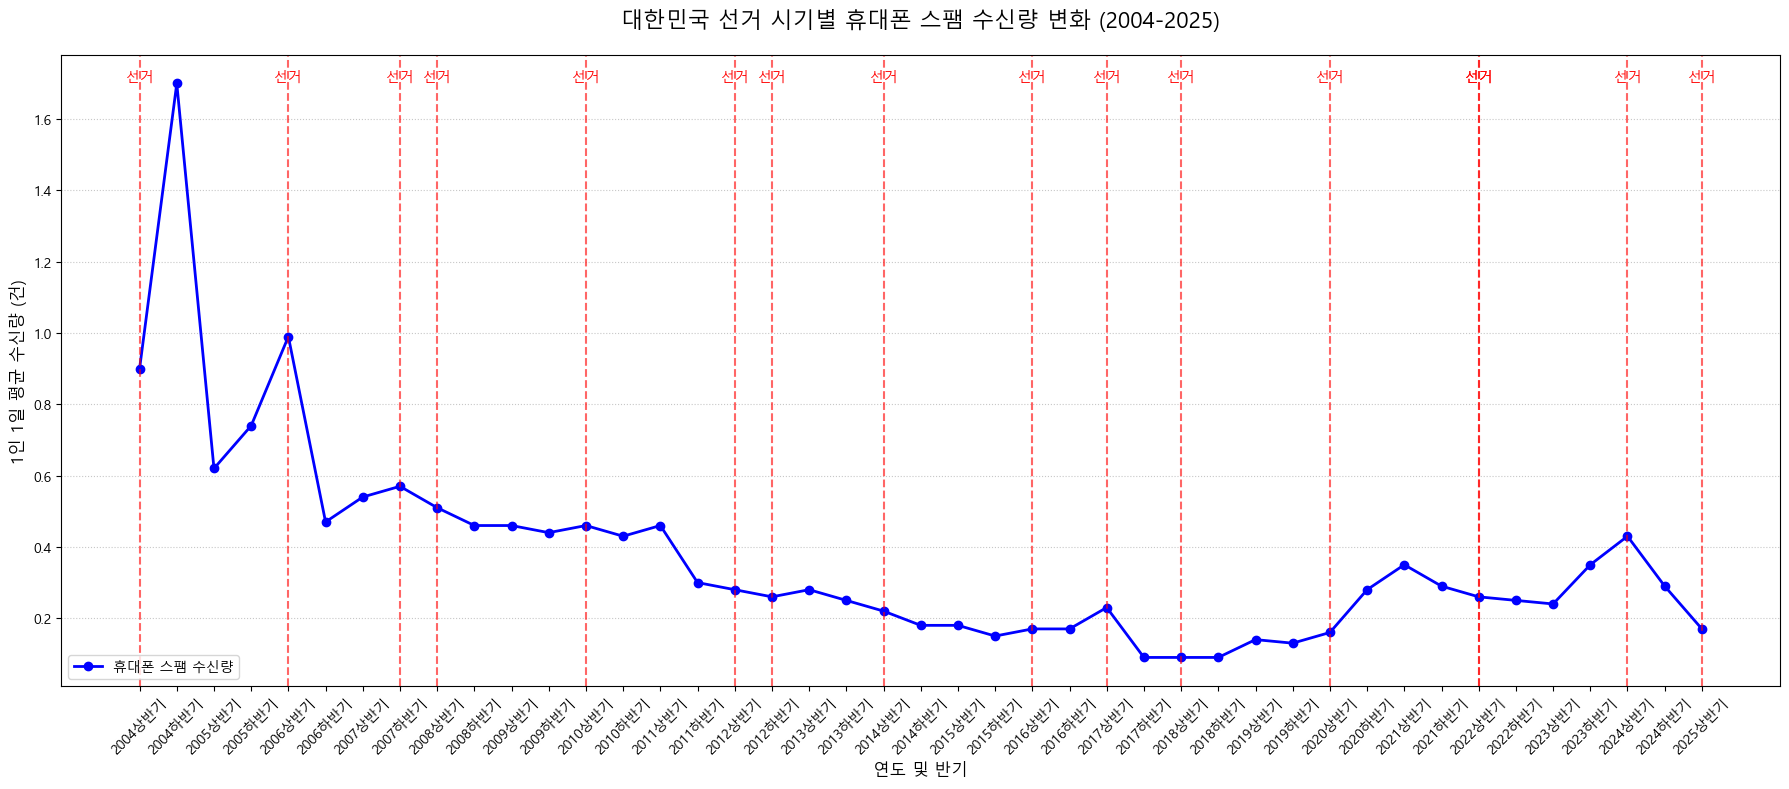

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 한글 폰트 설정 (환경에 따라 폰트 경로는 수정이 필요할 수 있습니다)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기
election_df = pd.read_csv('대한민국선거.csv')
spam_df = pd.read_csv('스팸_1인1일스팸수신량.csv', index_col=0, encoding = 'cp949')

# 3. 데이터 전처리 (휴대전화 스팸 행만 추출)
phone_spam = spam_df.loc['휴대전화스팸']

# x축(시계열) 설정을 위한 리스트
periods = phone_spam.index.tolist()
values = phone_spam.values.astype(float)

# 4. 선거 일정 데이터에서 '상반기/하반기' 키 생성
election_marks = []
for index, row in election_df.iterrows():
    year = row['연도'].replace('년', '').strip()
    month = int(row['선거일'].split('월')[0].strip())
    half = '상반기' if month <= 6 else '하반기'
    election_marks.append(f"{year}{half}")

# 5. 시각화
plt.figure(figsize=(18, 8))
plt.plot(periods, values, marker='o', linestyle='-', color='b', linewidth=2, label='휴대폰 스팸 수신량')

# 선거가 있었던 시점에 수직선 및 텍스트 표시
for mark in election_marks:
    if mark in periods:
        idx = periods.index(mark)
        plt.axvline(x=mark, color='red', linestyle='--', alpha=0.6)
        plt.text(mark, max(values), '선거', color='red', fontsize=10, ha='center', va='bottom')

plt.title('대한민국 선거 시기별 휴대폰 스팸 수신량 변화 (2004-2025)', fontsize=16, pad=20)
plt.xlabel('연도 및 반기', fontsize=12)
plt.ylabel('1인 1일 평균 수신량 (건)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

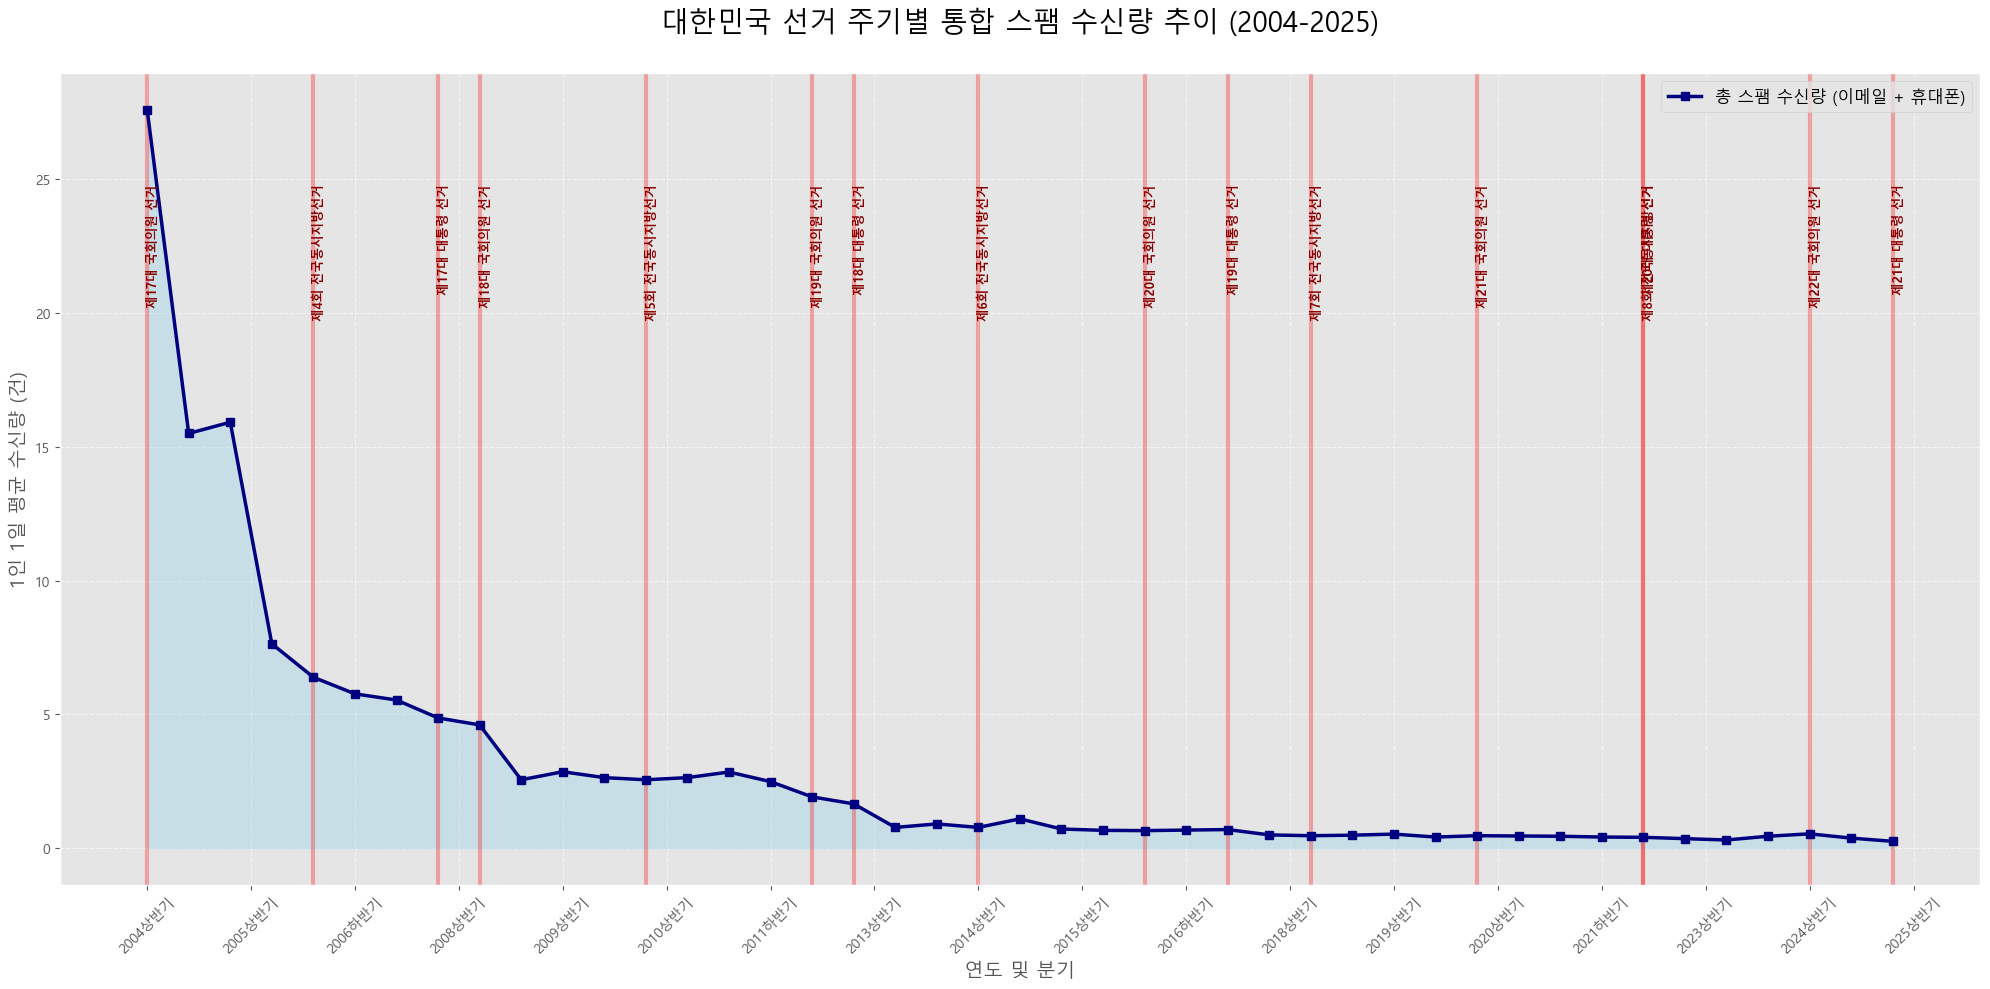

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot')

# 2. 데이터 로드
election_df = pd.read_csv('대한민국선거.csv')
spam_raw = pd.read_csv('스팸_1인1일스팸수신량.csv', index_col=0,encoding='cp949')

# 3. 데이터 전처리
# 이메일과 휴대폰 스팸 합산 (문자열 데이터일 경우를 대비해 float 변환)
spam_df = spam_raw.apply(pd.to_numeric, errors='coerce').fillna(0)
total_spam = spam_df.loc['이메일스팸'] + spam_df.loc['휴대전화스팸']

# x축 레이블(2004상반기, 2004하반기...)
periods = total_spam.index.tolist()
values = total_spam.values

# 4. 선거 이벤트 마킹 데이터 생성
election_events = []
for _, row in election_df.iterrows():
    year = str(row['연도']).replace('년', '').strip()
    month = int(row['선거일'].split('월')[0].strip())
    half = '상반기' if month <= 6 else '하반기'
    event_key = f"{year}{half}"
    if event_key in periods:
        election_events.append((event_key, row['선거 종류']))

# 5. 시각화
plt.figure(figsize=(20, 10))

# 스팸 총량 선 그래프
plt.plot(periods, values, marker='s', color='navy', linewidth=2.5, label='총 스팸 수신량 (이메일 + 휴대폰)')
plt.fill_between(periods, values, color='skyblue', alpha=0.3)

# 선거 시기 강조 (수직 막대 및 텍스트)
for event_key, label in election_events:
    plt.axvspan(event_key, event_key, color='red', alpha=0.3, linewidth=3)
    plt.text(event_key, max(values) * 0.9, label, rotation=90, 
             verticalalignment='top', color='darkred', weight='bold', fontsize=9)

# 그래프 서식 설정
plt.title('대한민국 선거 주기별 통합 스팸 수신량 추이 (2004-2025)', fontsize=20, pad=30)
plt.xlabel('연도 및 분기', fontsize=14)
plt.ylabel('1인 1일 평균 수신량 (건)', fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=12)

# x축 간격 조절
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(len(periods)//2)) 

plt.tight_layout()
plt.show()

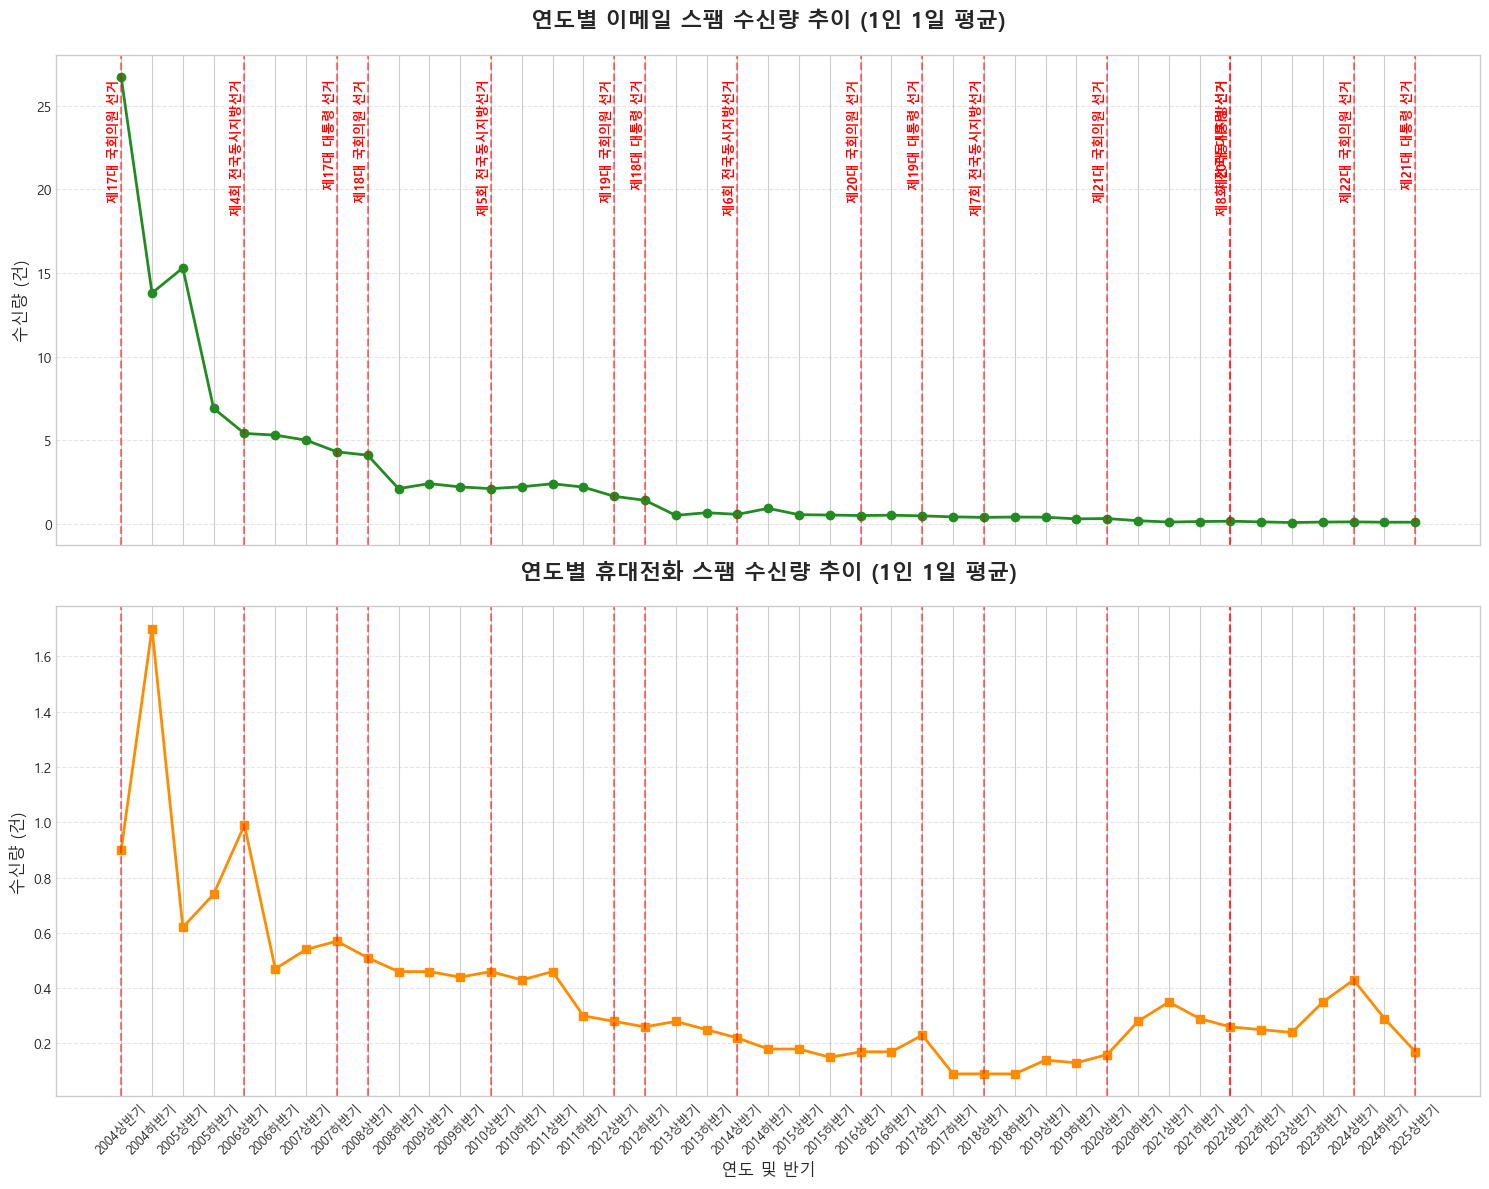

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1.한글 폰트 설정 (맑은 고딕)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 2. 데이터 로드
election_df = pd.read_csv('대한민국선거.csv')
spam_raw = pd.read_csv('스팸_1인1일스팸수신량.csv', index_col=0,encoding='cp949')

# 3. 데이터 전처리
spam_df = spam_raw.apply(pd.to_numeric, errors='coerce').fillna(0)
periods = spam_df.columns.tolist()

# 선거일 정보를 바탕으로 그래프에 표시할 이벤트 리스트 생성
election_events = []
for _, row in election_df.iterrows():
    year = str(row['연도']).replace('년', '').strip()
    month = int(row['선거일'].split('월')[0].strip())
    half = '상반기' if month <= 6 else '하반기'
    event_key = f"{year}{half}"
    if event_key in periods:
        election_events.append((event_key, row['선거 종류']))

# 4. 시각화 (위아래 2개 그래프)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# (1) 이메일 스팸 그래프
ax1.plot(periods, spam_df.loc['이메일스팸'], marker='o', color='forestgreen', label='이메일 스팸', linewidth=2)
ax1.set_title('연도별 이메일 스팸 수신량 추이 (1인 1일 평균)', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('수신량 (건)')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

# (2) 휴대전화 스팸 그래프
ax2.plot(periods, spam_df.loc['휴대전화스팸'], marker='s', color='darkorange', label='휴대전화 스팸', linewidth=2)
ax2.set_title('연도별 휴대전화 스팸 수신량 추이 (1인 1일 평균)', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel('수신량 (건)')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

# 선거 시점 표시 (빨간 점선 및 이름)
for ax in [ax1, ax2]:
    for event_key, label in election_events:
        ax.axvline(x=event_key, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
        if ax == ax1: # 첫 번째 그래프에만 선거 명칭 표시
            ax.text(event_key, ax.get_ylim()[1]*0.95, label, rotation=90, 
                    ha='right', va='top', color='red', fontsize=9, fontweight='bold')

plt.xticks(rotation=45, fontsize=9)
plt.xlabel('연도 및 반기')
plt.tight_layout()
plt.show()

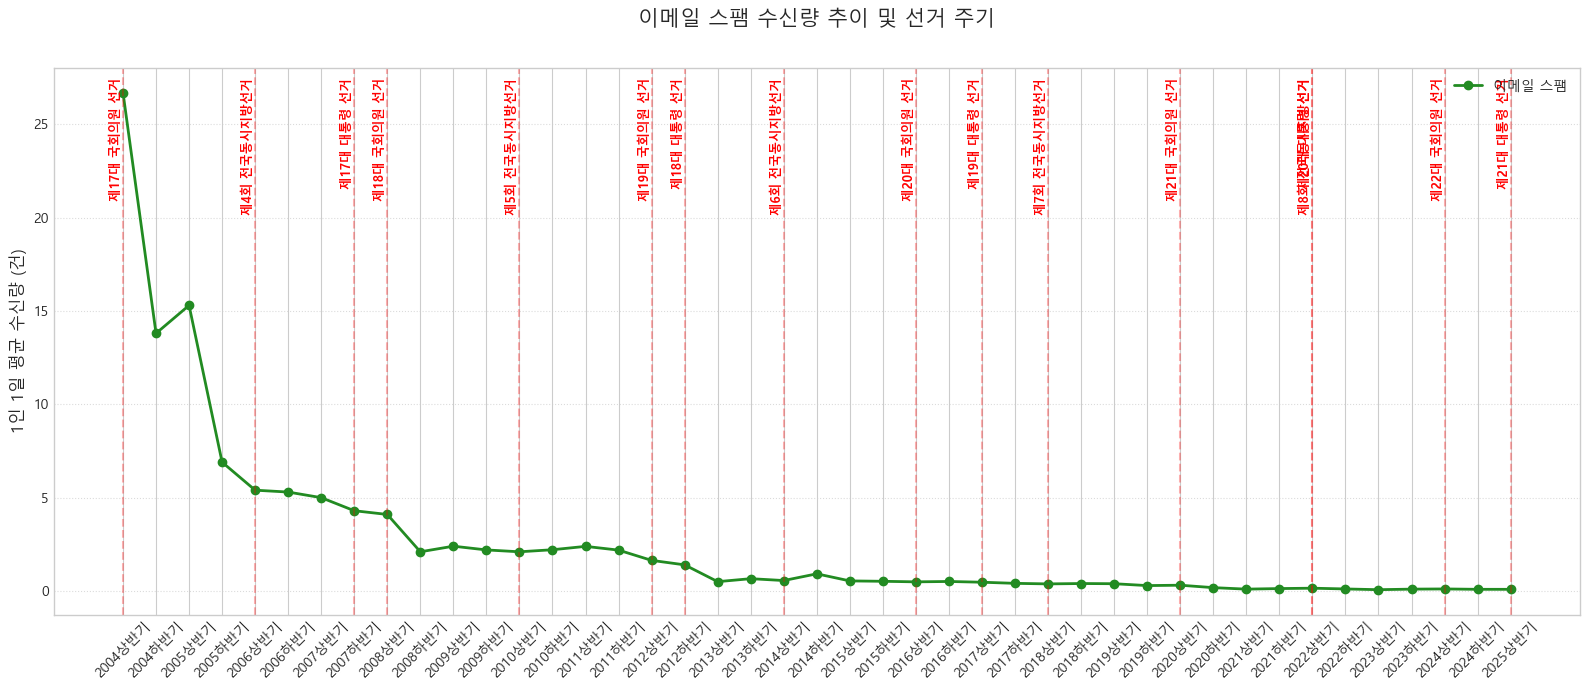

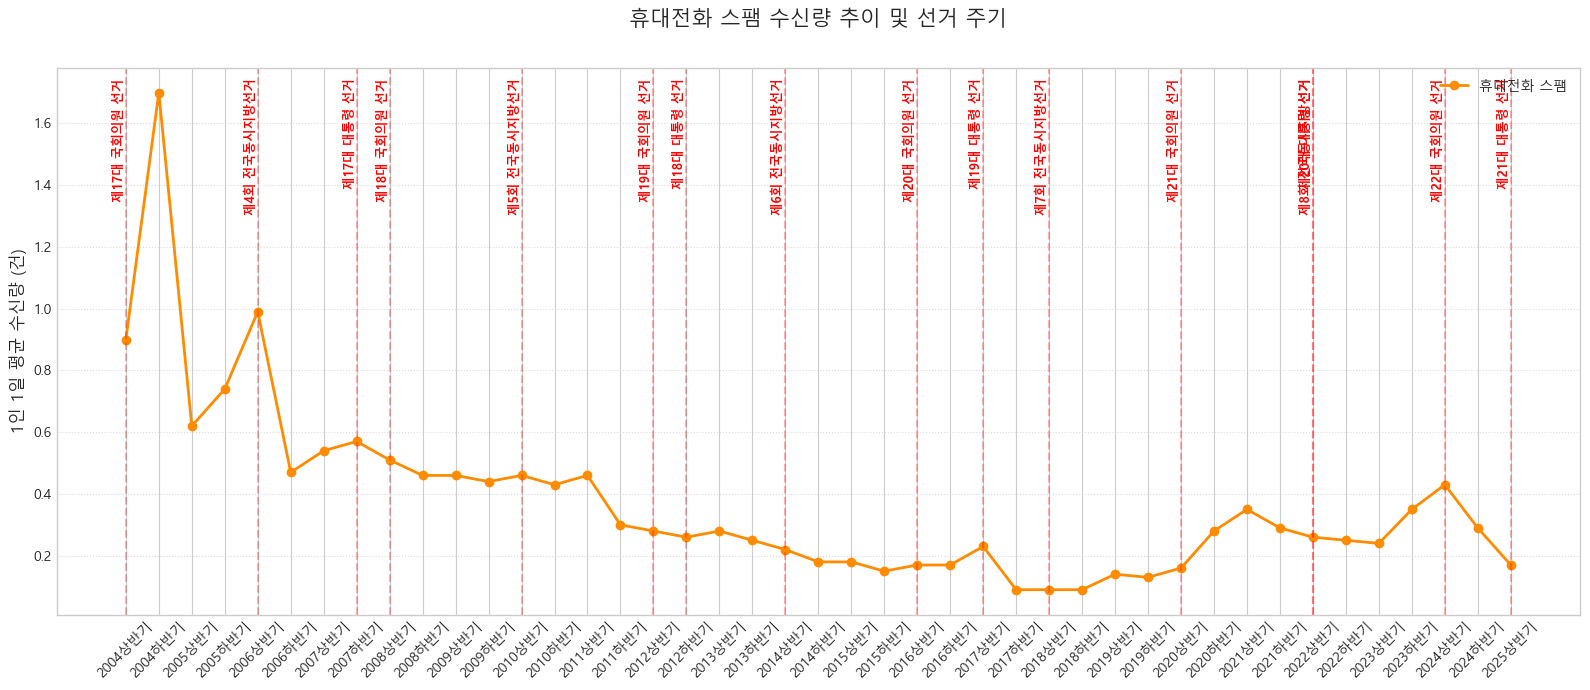

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기
election_df = pd.read_csv('대한민국선거.csv')
spam_raw = pd.read_csv('스팸_1인1일스팸수신량.csv', index_col=0,encoding='cp949')

# 3. 데이터 전처리
spam_df = spam_raw.apply(pd.to_numeric, errors='coerce').fillna(0)
periods = spam_df.columns.tolist()

election_events = []
for _, row in election_df.iterrows():
    year = str(row['연도']).replace('년', '').strip()
    month = int(row['선거일'].split('월')[0].strip())
    half = '상반기' if month <= 6 else '하반기'
    event_key = f"{year}{half}"
    if event_key in periods:
        election_events.append((event_key, row['선거 종류']))

# 4. 시각화 함수
def plot_spam_data_v2(data_row, title, color):
    plt.figure(figsize=(16, 7)) # 높이를 약간 늘려 가독성 확보
    plt.plot(periods, data_row, marker='o', color=color, linewidth=2, label=title)
    
    # y축 최댓값의 95% 지점에 텍스트가 오도록 설정
    y_max = data_row.max()
    
    # 선거 시점 표시
    for event_key, label in election_events:
        plt.axvline(x=event_key, color='red', linestyle='--', alpha=0.3)
        # va='top'으로 설정하여 점선 시작점 아래(안쪽)로 글자가 들어오게 함
        plt.text(event_key, plt.ylim()[1] * 0.98, label, rotation=90, 
                 ha='right', va='top', color='red', fontsize=9, fontweight='bold')
    
    plt.title(f'{title} 수신량 추이 및 선거 주기', fontsize=15, pad=30)
    plt.ylabel('1인 1일 평균 수신량 (건)')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# 5. 실행
plot_spam_data_v2(spam_df.loc['이메일스팸'], '이메일 스팸', 'forestgreen')
plot_spam_data_v2(spam_df.loc['휴대전화스팸'], '휴대전화 스팸', 'darkorange')

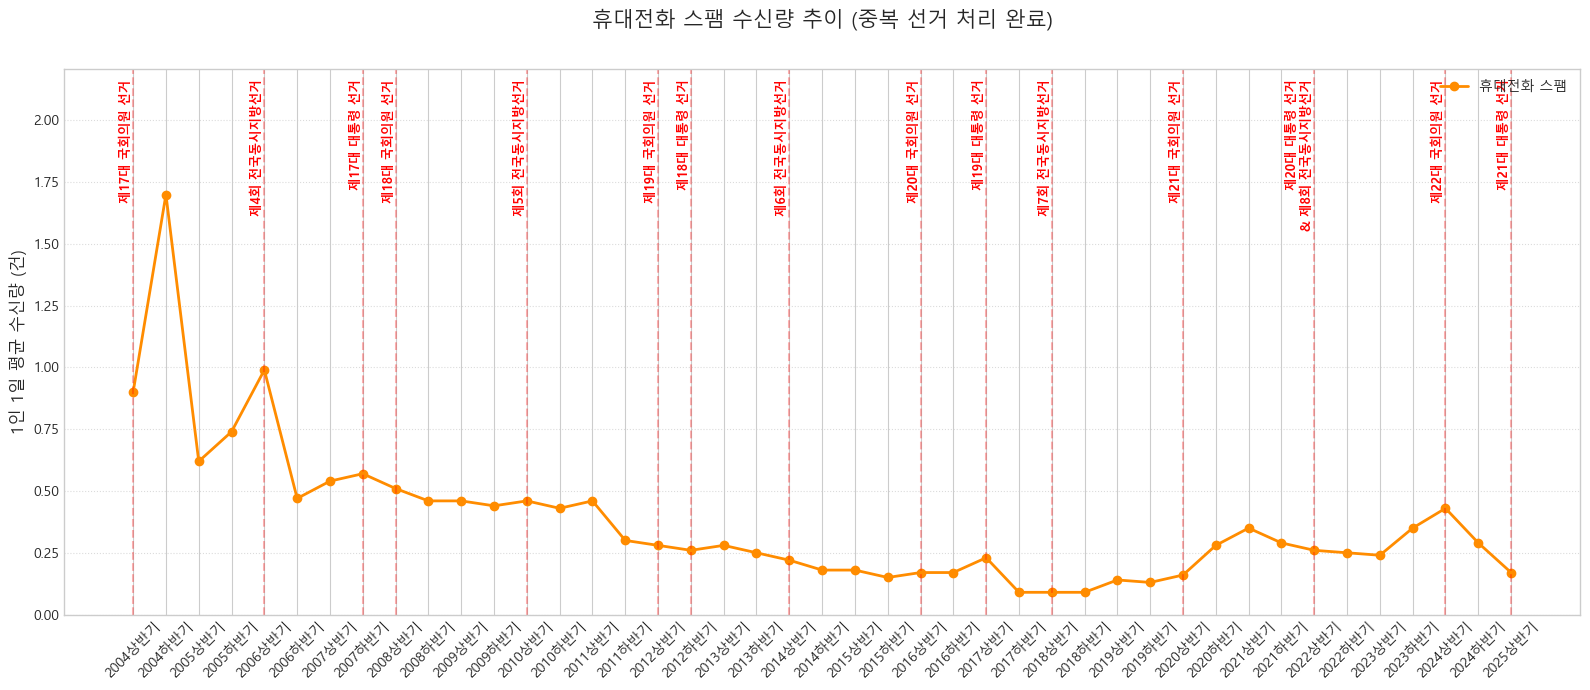

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 및 전처리
election_df = pd.read_csv('대한민국선거.csv')
spam_raw = pd.read_csv('스팸_1인1일스팸수신량.csv', index_col=0,encoding='cp949')
spam_df = spam_raw.apply(pd.to_numeric, errors='coerce').fillna(0)
periods = spam_df.columns.tolist()

# 3. 선거 데이터 병합
election_dict = {}
for _, row in election_df.iterrows():
    year = str(row['연도']).replace('년', '').strip()
    month = int(row['선거일'].split('월')[0].strip())
    half = '상반기' if month <= 6 else '하반기'
    event_key = f"{year}{half}"
    
    if event_key in periods:
        name = row['선거 종류']
        if event_key not in election_dict:
            election_dict[event_key] = name
        else:
            # 이미 선거가 있다면 줄바꿈(\n)을 넣어 합칩니다.
            election_dict[event_key] += f"\n& {name}"

# 4. 시각화 함수
def plot_spam_refined(data_row, title, color):
    plt.figure(figsize=(16, 7))
    plt.plot(periods, data_row, marker='o', color=color, linewidth=2, label=title)
    
    # y축 상단 여유 공간 확보
    current_ymax = data_row.max()
    plt.ylim(0, current_ymax * 1.3) 
    
    # 선거 시점 표시
    for event_key, combined_name in election_dict.items():
        plt.axvline(x=event_key, color='red', linestyle='--', alpha=0.3)
        # 병합된 텍스트 출력
        plt.text(event_key, plt.ylim()[1] * 0.98, combined_name, 
                 rotation=90, ha='right', va='top', 
                 color='red', fontsize=9, fontweight='bold',
                 linespacing=1.2) # 줄 간격 조절
    
    plt.title(f'{title} 수신량 추이', fontsize=15, pad=30)
    plt.ylabel('1인 1일 평균 수신량 (건)')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# 5. 실행
plot_spam_refined(spam_df.loc['휴대전화스팸'], '휴대전화 스팸', 'darkorange')

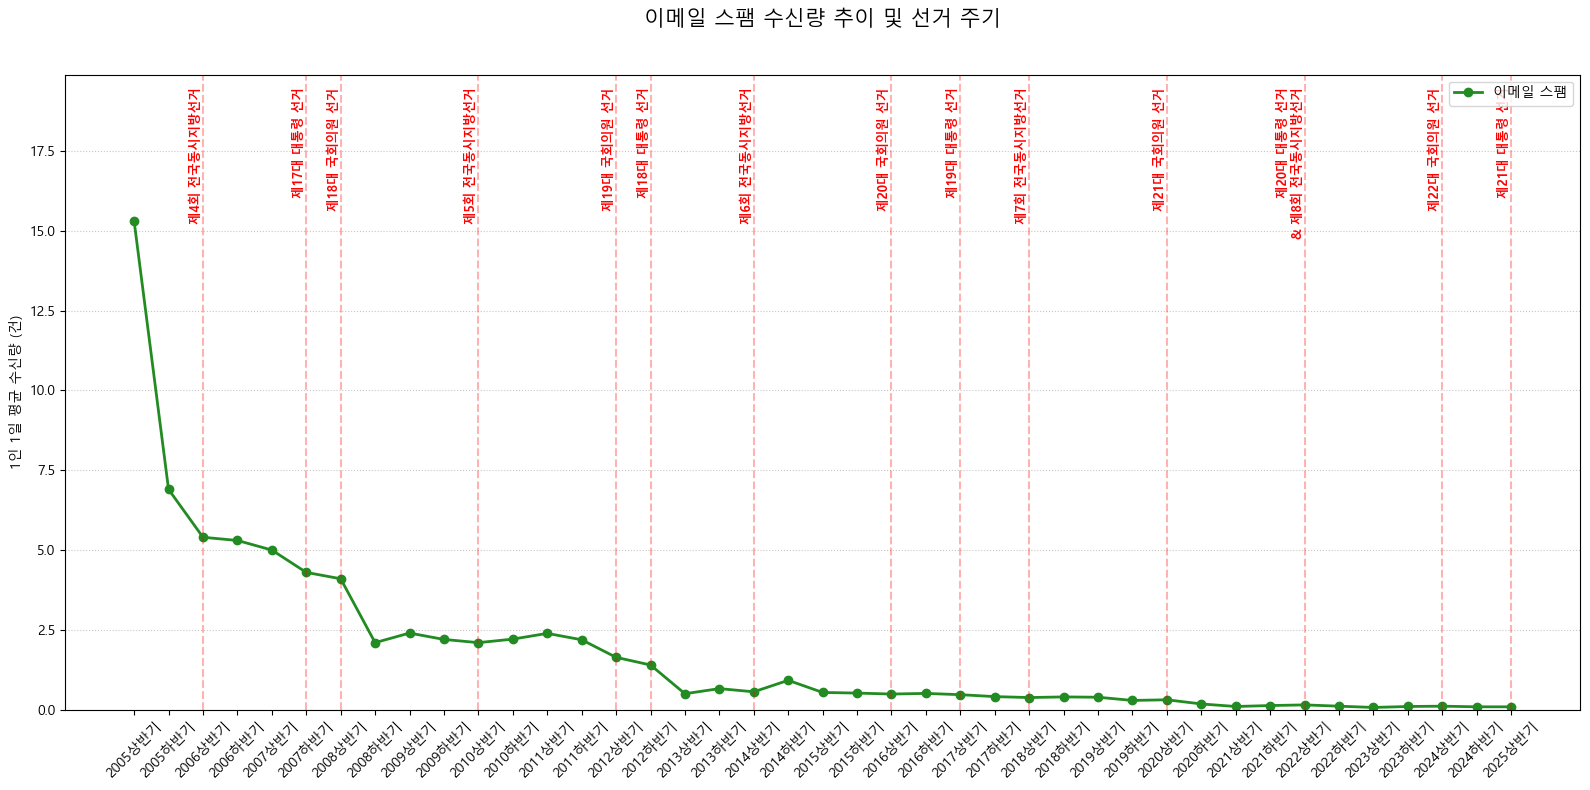

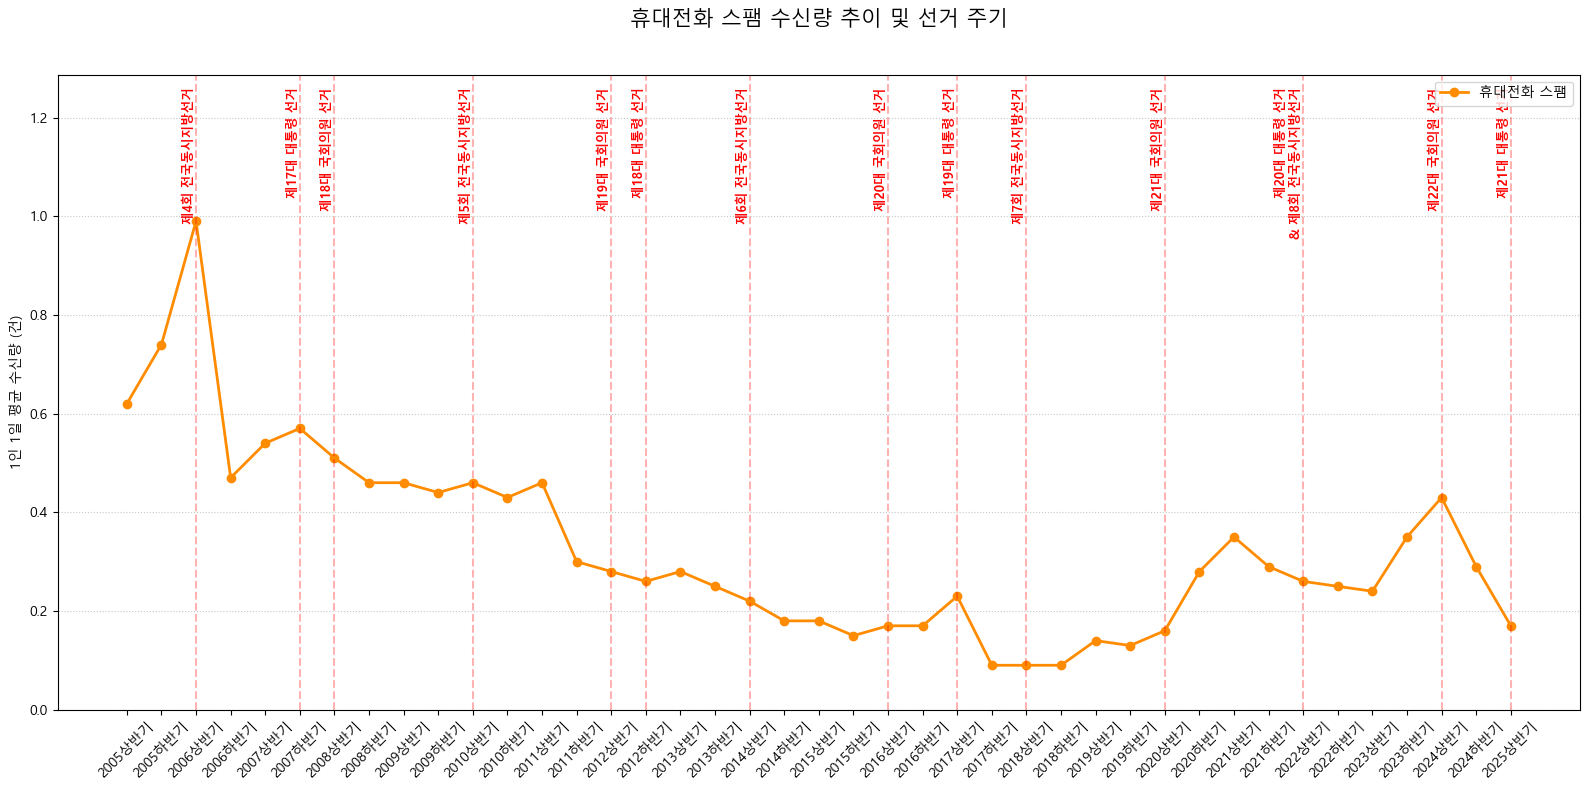

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기
election_df = pd.read_csv('대한민국선거.csv',encoding='cp949')
spam_raw = pd.read_csv('스팸_1인1일스팸수신량.csv', index_col=0, encoding='cp949')

# 3. 데이터 전처리
spam_df = spam_raw.apply(pd.to_numeric, errors='coerce').fillna(0)
periods = spam_df.columns.tolist()

# 동일한 시기(event_key)에 있는 선거 명칭을 하나로 합칩니다.
election_dict = {}
for _, row in election_df.iterrows():
    year = str(row['연도']).replace('년', '').strip()
    month = int(row['선거일'].split('월')[0].strip())
    half = '상반기' if month <= 6 else '하반기'
    event_key = f"{year}{half}"
    
    if event_key in periods:
        name = row['선거 종류']
        if event_key not in election_dict:
            election_dict[event_key] = name
        else:
            # 같은 시기에 선거가 또 있다면 줄바꿈(\n)과 기호(&)로 연결
            election_dict[event_key] += f"\n& {name}"

# 4. 시각화 함수
def plot_spam_data_v3(data_row, title, color):
    plt.figure(figsize=(16, 8)) # 텍스트 공간을 위해 높이를 조금 더 확보
    plt.plot(periods, data_row, marker='o', color=color, linewidth=2, label=title)
    
    # 상단 여백 확보: y축 최댓값을 실제 데이터보다 30% 높게 설정 (텍스트 자리)
    y_limit = data_row.max() * 1.3
    plt.ylim(0, y_limit)
    
    # 병합된 선거 데이터 표시
    for event_key, combined_label in election_dict.items():
        plt.axvline(x=event_key, color='red', linestyle='--', alpha=0.3)
        # va='top'으로 그래프 내부 상단에 배치
        plt.text(event_key, plt.ylim()[1] * 0.98, combined_label, 
                 rotation=90, ha='right', va='top', 
                 color='red', fontsize=9, fontweight='bold', linespacing=1.2)
    
    plt.title(f'{title} 수신량 추이 및 선거 주기', fontsize=15, pad=35)
    plt.ylabel('1인 1일 평균 수신량 (건)')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# 5. 실행
plot_spam_data_v3(spam_df.loc['이메일스팸'], '이메일 스팸', 'forestgreen')
plot_spam_data_v3(spam_df.loc['휴대전화스팸'], '휴대전화 스팸', 'darkorange')

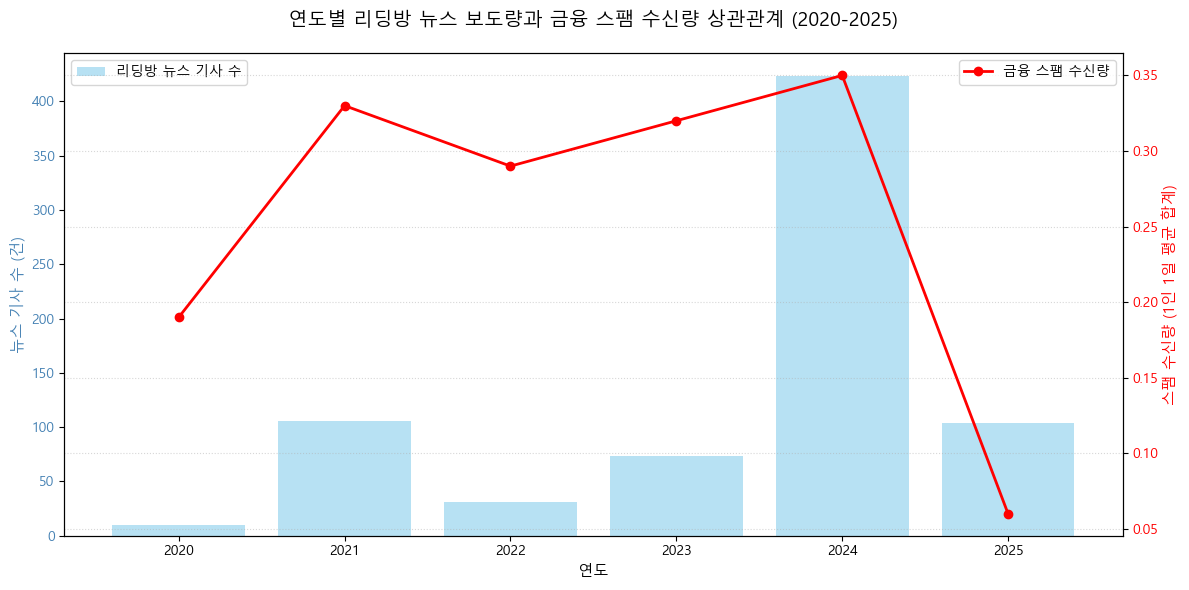

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
naver_df = pd.read_csv('naver_리딩방스팸.csv')
email_df = pd.read_csv('email_20202025.csv',encoding='cp949')
sms_df = pd.read_csv('smsvoice_20202025.csv',encoding='cp949')

# 3. 뉴스 기사 수 전처리 (pubDate에서 연도 추출)
naver_df['year'] = naver_df['pubDate'].str.extract(r'(\d{4})')
news_counts = naver_df['year'].value_counts().sort_index()

# 4. 스팸 데이터 전처리 함수 (연도별 금융/대출 스팸 합산)
def get_yearly_finance_spam(df):
    # 첫 번째 열을 인덱스로 설정 (유형명)
    df_clean = df.copy()
    # '금융' 포함된 행 필터링
    target = df_clean[df_clean.iloc[:, 0].str.contains('금융', na=False)]
    if target.empty: return pd.Series(dtype=float)
    
    # 반기 데이터(2020.1/2 등)를 연도로 묶어 합산
    data = target.iloc[0, 1:].astype(float)
    yearly = data.groupby(lambda x: x.split('.')[0]).sum()
    return yearly

email_finance = get_yearly_finance_spam(email_df)
sms_finance = get_yearly_finance_spam(sms_df)

# 5. 데이터 병합 (2020-2025 범위)
years = [str(y) for y in range(2020, 2026)]
news_plot = news_counts.reindex(years).fillna(0)
total_spam_plot = (email_finance + sms_finance).reindex(years).fillna(0)

# 6. 시각화
fig, ax1 = plt.subplots(figsize=(12, 6))

# 막대 그래프: 뉴스 기사 수 (관심도)
ax1.bar(years, news_plot, color='skyblue', alpha=0.6, label='리딩방 뉴스 기사 수')
ax1.set_xlabel('연도', fontsize=11)
ax1.set_ylabel('뉴스 기사 수 (건)', color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')

# 꺾은선 그래프: 실제 스팸 수신량 (금융 합계)
ax2 = ax1.twinx()
ax2.plot(years, total_spam_plot, color='red', marker='o', linewidth=2, label='금융 스팸 수신량')
ax2.set_ylabel('스팸 수신량 (1인 1일 평균 합계)', color='red', fontsize=11)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('연도별 리딩방 뉴스 보도량과 금융 스팸 수신량 상관관계 (2020-2025)', fontsize=14, pad=20)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_12332\392747935.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(all_periods, rotation=45)


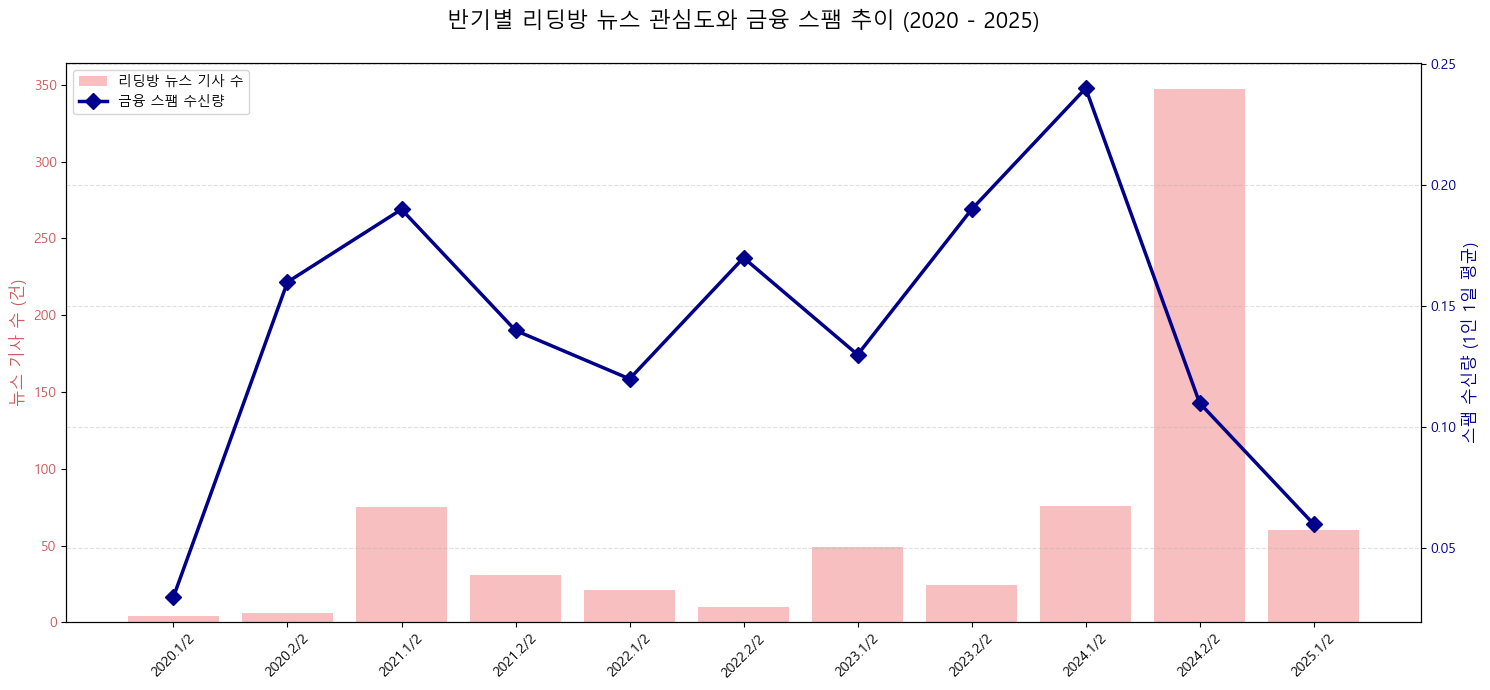

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
naver_df = pd.read_csv('naver_리딩방스팸.csv')
email_df = pd.read_csv('email_20202025.csv',encoding='cp949')
sms_df = pd.read_csv('smsvoice_20202025.csv',encoding='cp949')

# 3. 뉴스 데이터 전처리 (반기별 분류)
# pubDate 예시: "Thu, 09 Apr 2026..." -> 연도와 월 추출
naver_df['dt'] = pd.to_datetime(naver_df['pubDate'], errors='coerce')
naver_df = naver_df.dropna(subset=['dt'])

def get_half_year(dt):
    year = dt.year
    half = '1/2' if dt.month <= 6 else '2/2'
    return f"{year}.{half}"

naver_df['period'] = naver_df['dt'].apply(get_half_year)
news_half_counts = naver_df['period'].value_counts().sort_index()

# 4. 스팸 데이터 전처리 (금융/불법대출 유형 추출)
def get_half_finance_spam(df):
    # 금융/불법대출 관련 키워드 행 필터링
    target = df[df.iloc[:, 0].str.contains('금융', na=False)]
    if target.empty: return pd.Series(dtype=float)
    
    # 첫 번째 행의 수치 데이터 추출 (컬럼명: 2020.1/2 등)
    return target.iloc[0, 1:].astype(float)

email_half = get_half_finance_spam(email_df)
sms_half = get_half_finance_spam(sms_df)

# 5. 데이터 통합 (X축 기준 설정)
all_periods = email_half.index.tolist()
news_plot = news_half_counts.reindex(all_periods).fillna(0)
total_spam_plot = (email_half + sms_half).reindex(all_periods).fillna(0)

# 6. 시각화
fig, ax1 = plt.subplots(figsize=(15, 7))

# 막대 그래프: 반기별 뉴스 기사 수
bars = ax1.bar(all_periods, news_plot, color='lightcoral', alpha=0.5, label='리딩방 뉴스 기사 수')
ax1.set_ylabel('뉴스 기사 수 (건)', color='indianred', fontsize=12)
ax1.tick_params(axis='y', labelcolor='indianred')

# 꺾은선 그래프: 반기별 금융/대출 스팸 합계
ax2 = ax1.twinx()
line = ax2.plot(all_periods, total_spam_plot, color='darkblue', marker='D', 
                markersize=8, linewidth=2.5, label='금융 스팸 수신량')
ax2.set_ylabel('스팸 수신량 (1인 1일 평균)', color='darkblue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkblue')

# 서식 정리
plt.title('반기별 리딩방 뉴스 관심도와 금융 스팸 추이 (2020 - 2025)', fontsize=16, pad=25)
ax1.set_xticklabels(all_periods, rotation=45)

# 범례 통합
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

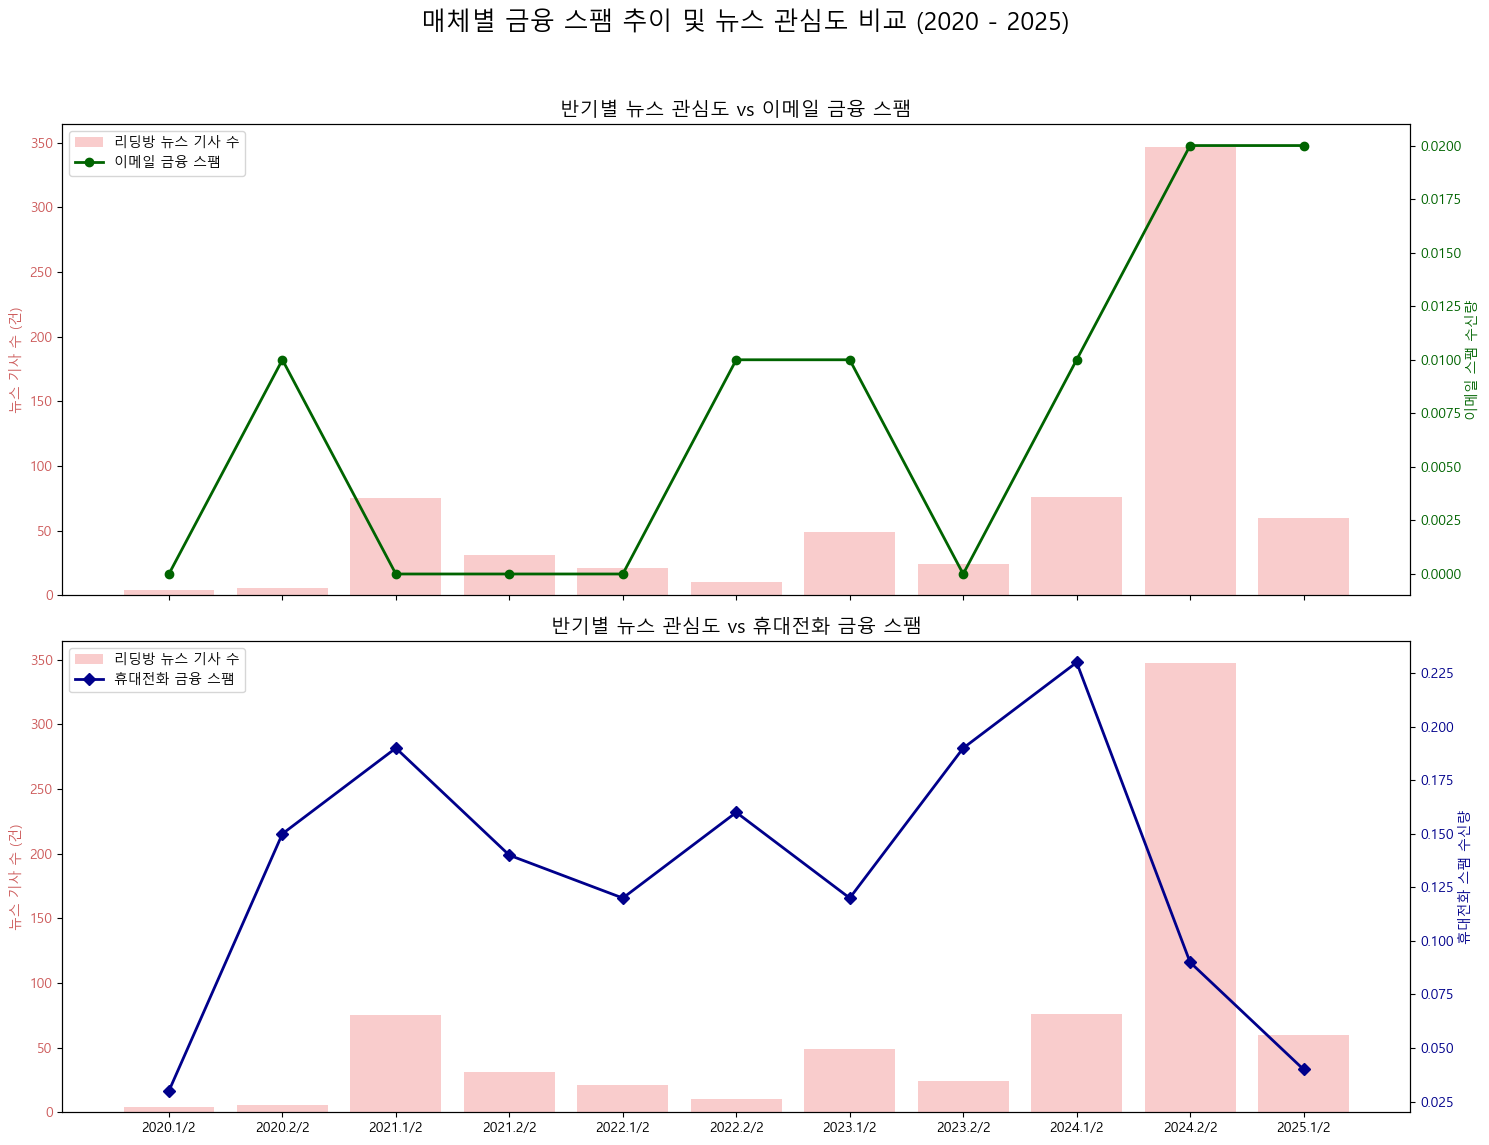

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
naver_df = pd.read_csv('naver_리딩방스팸.csv')
email_df = pd.read_csv('email_20202025.csv', encoding='cp949')
sms_df = pd.read_csv('smsvoice_20202025.csv', encoding='cp949')

# 3. 뉴스 데이터 전처리 (반기별 분류)
naver_df['dt'] = pd.to_datetime(naver_df['pubDate'], errors='coerce')
naver_df = naver_df.dropna(subset=['dt'])

def get_half_year(dt):
    year = dt.year
    half = '1/2' if dt.month <= 6 else '2/2'
    return f"{year}.{half}"

naver_df['period'] = naver_df['dt'].apply(get_half_year)
news_half_counts = naver_df['period'].value_counts().sort_index()

# 4. 스팸 데이터 전처리 함수
def get_half_finance_spam(df):
    target = df[df.iloc[:, 0].str.contains('금융', na=False)]
    if target.empty: return pd.Series(dtype=float)
    return target.iloc[0, 1:].astype(float)

email_half = get_half_finance_spam(email_df)
sms_half = get_half_finance_spam(sms_df)

# 5. 데이터 통합 (X축 기준 설정)
all_periods = email_half.index.tolist()
news_plot = news_half_counts.reindex(all_periods).fillna(0)

# 6. 시각화 (2행 1열 구조)
fig, (ax_email, ax_sms) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# --- 첫 번째 서브플롯: 이메일 스팸 ---
# 뉴스 기사 수 (막대)
ax_email.bar(all_periods, news_plot, color='lightcoral', alpha=0.4, label='리딩방 뉴스 기사 수')
ax_email.set_ylabel('뉴스 기사 수 (건)', color='indianred')
ax_email.tick_params(axis='y', labelcolor='indianred')

# 이메일 스팸 (꺾은선)
ax_email_2 = ax_email.twinx()
ax_email_2.plot(all_periods, email_half, color='darkgreen', marker='o', linewidth=2, label='이메일 금융 스팸')
ax_email_2.set_ylabel('이메일 스팸 수신량', color='darkgreen')
ax_email_2.tick_params(axis='y', labelcolor='darkgreen')
ax_email.set_title('반기별 뉴스 관심도 vs 이메일 금융 스팸', fontsize=14)

# --- 두 번째 서브플롯: 휴대전화 스팸 ---
# 뉴스 기사 수 (막대)
ax_sms.bar(all_periods, news_plot, color='lightcoral', alpha=0.4, label='리딩방 뉴스 기사 수')
ax_sms.set_ylabel('뉴스 기사 수 (건)', color='indianred')
ax_sms.tick_params(axis='y', labelcolor='indianred')

# 휴대전화 스팸 (꺾은선)
ax_sms_2 = ax_sms.twinx()
ax_sms_2.plot(all_periods, sms_half, color='darkblue', marker='D', linewidth=2, label='휴대전화 금융 스팸')
ax_sms_2.set_ylabel('휴대전화 스팸 수신량', color='darkblue')
ax_sms_2.tick_params(axis='y', labelcolor='darkblue')
ax_sms.set_title('반기별 뉴스 관심도 vs 휴대전화 금융 스팸', fontsize=14)

# 서식 정리
plt.xticks(rotation=45)
fig.suptitle('매체별 금융 스팸 추이 및 뉴스 관심도 비교 (2020 - 2025)', fontsize=18, y=0.98)

# 범례 통합 표시 (각 서브플롯별)
for ax, ax2 in [(ax_email, ax_email_2), (ax_sms, ax_sms_2)]:
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_12332\1451795131.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(all_periods, rotation=45)


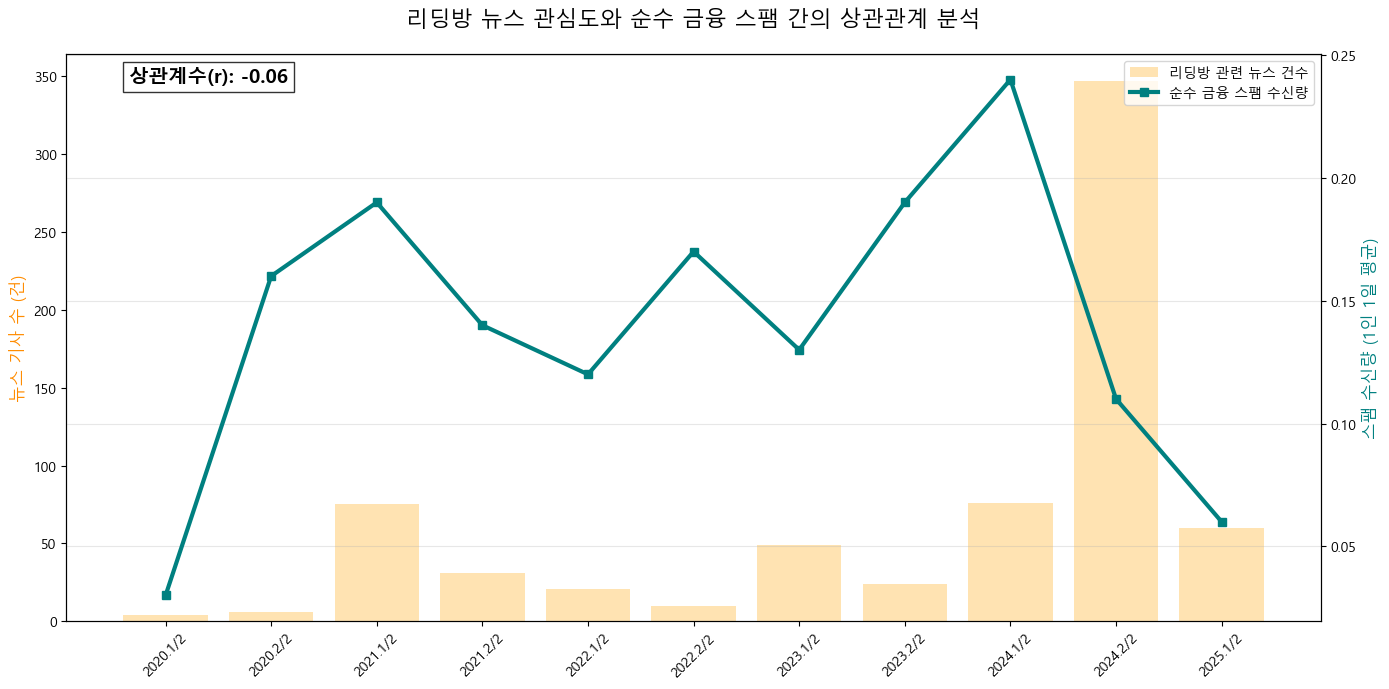

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 한글 폰트 및 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
naver_df = pd.read_csv('naver_리딩방스팸.csv')
email_df = pd.read_csv('email_20202025.csv', encoding='cp949')
sms_df = pd.read_csv('smsvoice_20202025.csv', encoding='cp949')

# 3. 뉴스 데이터 전처리
naver_df['dt'] = pd.to_datetime(naver_df['pubDate'], errors='coerce')
naver_df = naver_df.dropna(subset=['dt'])
naver_df['period'] = naver_df['dt'].apply(lambda x: f"{x.year}.{'1/2' if x.month <= 6 else '2/2'}")
news_counts = naver_df['period'].value_counts().sort_index()

# 4. 금융 스팸 데이터 추출 함수
def get_pure_finance_spam(df):

    target = df[df.iloc[:, 0].str.contains('금융', na=False)]
    if target.empty: return pd.Series(dtype=float)
    return target.iloc[0, 1:].astype(float)

email_finance = get_pure_finance_spam(email_df)
sms_finance = get_pure_finance_spam(sms_df)

# 5. 데이터 통합 및 상관관계 계산
all_periods = email_finance.index.tolist()
news_data = news_counts.reindex(all_periods).fillna(0)
total_finance_spam = (email_finance + sms_finance).reindex(all_periods).fillna(0)

# 상관계수 계산 (피어슨 상관계수)
correlation = np.corrcoef(news_data, total_finance_spam)[0, 1]

# 6. 시각화
fig, ax1 = plt.subplots(figsize=(14, 7))

# 뉴스 데이터 (막대)
ax1.bar(all_periods, news_data, color='orange', alpha=0.3, label='리딩방 관련 뉴스 건수')
ax1.set_ylabel('뉴스 기사 수 (건)', color='darkorange', fontsize=12)

# 금융 스팸 (꺾은선)
ax2 = ax1.twinx()
ax2.plot(all_periods, total_finance_spam, color='teal', marker='s', linewidth=3, label='순수 금융 스팸 수신량')
ax2.set_ylabel('스팸 수신량 (1인 1일 평균)', color='teal', fontsize=12)

# 상관관계 텍스트 박스 추가
plt.text(0.05, 0.95, f'상관계수(r): {correlation:.2f}', transform=ax1.transAxes, 
         fontsize=14, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

plt.title('리딩방 뉴스 관심도와 순수 금융 스팸 간의 상관관계 분석', fontsize=16, pad=20)
ax1.set_xticklabels(all_periods, rotation=45)
plt.grid(True, axis='y', alpha=0.3)

# 범례
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.tight_layout()
plt.show()

2020-2025 리딩방 뉴스 기사 수와 금융 스팸 간의 상관계수: 0.3008


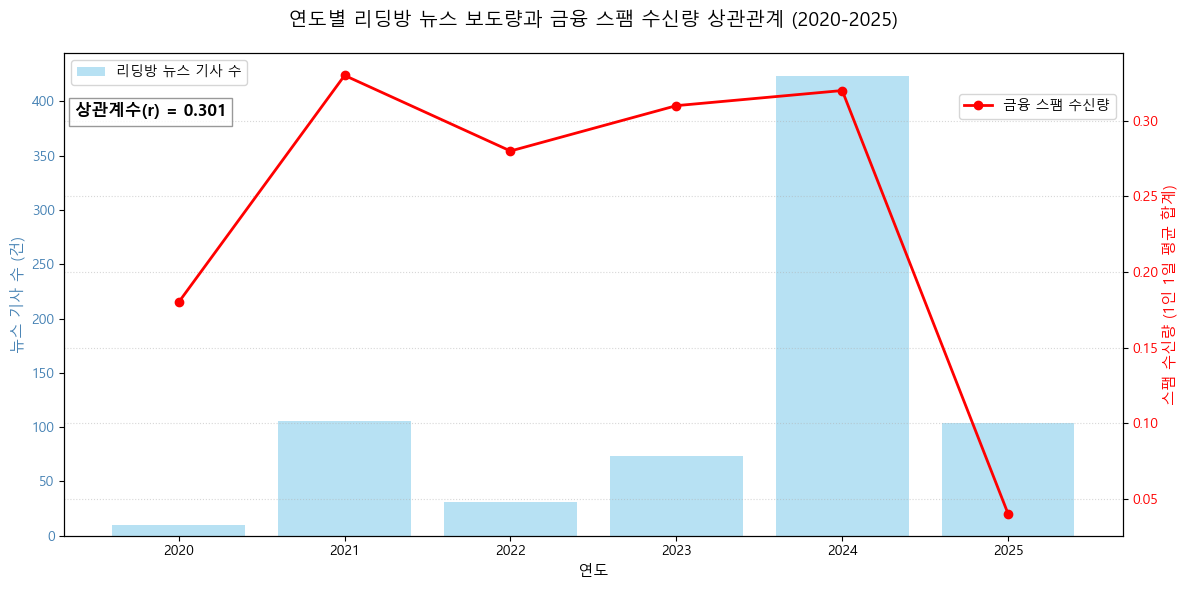

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
naver_df = pd.read_csv('naver_리딩방스팸.csv')
sms_df = pd.read_csv('smsvoice_20202025.csv', encoding='cp949')

# 3. 뉴스 기사 수 전처리
naver_df['year'] = naver_df['pubDate'].str.extract(r'(\d{4})')
news_counts = naver_df['year'].value_counts().sort_index()

# 4. 스팸 데이터 전처리 함수
def get_yearly_finance_spam(df):
    df_clean = df.copy()
    target = df_clean[df_clean.iloc[:, 0].str.contains('금융', na=False)]
    if target.empty: return pd.Series(dtype=float)
    
    data = target.iloc[0, 1:].astype(float)
    yearly = data.groupby(lambda x: x.split('.')[0]).sum()
    return yearly

sms_finance = get_yearly_finance_spam(sms_df)

# 5. 데이터 병합 (2020-2025 범위)
years = [str(y) for y in range(2020, 2026)]
news_plot = news_counts.reindex(years).fillna(0)
total_spam_plot = sms_finance.reindex(years).fillna(0)


# pandas의 corr() 함수를 사용하기 위해 시리즈를 합쳐 임시 데이터프레임 생성
correlation_df = pd.DataFrame({
    'news': news_plot,
    'spam': total_spam_plot
})
correlation_value = correlation_df['news'].corr(correlation_df['spam'])

print(f"2020-2025 리딩방 뉴스 기사 수와 금융 스팸 간의 상관계수: {correlation_value:.4f}")
# ------------------------------

# 6. 시각화
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(years, news_plot, color='skyblue', alpha=0.6, label='리딩방 뉴스 기사 수')
ax1.set_xlabel('연도', fontsize=11)
ax1.set_ylabel('뉴스 기사 수 (건)', color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(years, total_spam_plot, color='red', marker='o', linewidth=2, label='금융 스팸 수신량')
ax2.set_ylabel('스팸 수신량 (1인 1일 평균 합계)', color='red', fontsize=11)
ax2.tick_params(axis='y', labelcolor='red')


plt.text(0.01, 0.87, f'상관계수(r) = {correlation_value:.3f}', 
         transform=ax1.transAxes, fontsize=12, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
# --------------------------------------------

plt.title('연도별 리딩방 뉴스 보도량과 금융 스팸 수신량 상관관계 (2020-2025)', fontsize=14, pad=20)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.93)) # 범례 겹침 방지 조절
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()